In [ ]:

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Dataset: Read

In [ ]:
FILE_ID = "1PPp0KKJ7wBMex3loW0dAruk_6cBaztPY"

url = f"https://drive.google.com/uc?export=download&id={FILE_ID}"

df = pd.read_csv(url)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (1529, 22)


,Sex,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Blood Pressure (mmHg),Total Cholesterol (mg/dL),HDL (mg/dL),Fasting Blood Sugar (mg/dL),...,Physical Activity Level,Family History of CVD,Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Blood Pressure Category,Estimated LDL (mg/dL),CVD Risk Score,CVD Risk Level
0,F,32.0,69.1,1.71,23.6,86.2,125/79,248.0,78.0,111.0,...,Low,N,171.0,0.504,125.0,79.0,Elevated,140.0,17.93,INTERMEDIARY
1,F,55.0,118.7,1.69,41.6,82.5,139/70,162.0,50.0,135.0,...,High,Y,169.0,0.488,139.0,70.0,Hypertension Stage 1,82.0,20.51,HIGH
2,M,NaN,NaN,1.83,26.9,106.7,104/77,103.0,73.0,114.0,...,High,Y,183.0,0.583,104.0,77.0,Normal,0.0,12.64,INTERMEDIARY
3,M,44.0,108.3,1.80,33.4,96.6,140/83,134.0,46.0,91.0,...,High,Y,NaN,0.537,140.0,83.0,Hypertension Stage 1,58.0,16.36,INTERMEDIARY
4,F,32.0,99.5,1.86,28.8,102.7,144/83,146.0,64.0,141.0,...,High,N,186.0,0.552,144.0,83.0,Hypertension Stage 1,52.0,17.88,INTERMEDIARY


# Dataset Overview

In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nMissing values:")
missing = df.isnull().sum().sort_values(ascending=False)
display(missing[missing > 0].to_frame("missing_count"))

print("\nTarget distributions:")
display(df["CVD Risk Level"].value_counts())

Rows: 1529
Columns: 22

Data types:


,dtype
Sex,object
Age,float64
Weight (kg),float64
Height (m),float64
BMI,float64
Abdominal Circumference (cm),float64
Blood Pressure (mmHg),object
Total Cholesterol (mg/dL),float64
HDL (mg/dL),float64
Fasting Blood Sugar (mg/dL),float64



Duplicate rows: 0

Missing values:


,missing_count
Diastolic BP,82
Weight (kg),81
HDL (mg/dL),80
Waist-to-Height Ratio,79
Age,78
Height (cm),74
Total Cholesterol (mg/dL),73
Systolic BP,71
CVD Risk Score,70
Estimated LDL (mg/dL),69



Target distributions:


,count
CVD Risk Level,
HIGH,728
INTERMEDIARY,581
LOW,220


# Data Cleaning & Feature Recovery

In [ ]:
data = df.copy()

# Recover systolic/diastolic BP from the complete BP string where needed.
bp_parts = data["Blood Pressure (mmHg)"].str.extract(r"(?P<bp_sys>\d+(?:\.\d+)?)/(?P<bp_dia>\d+(?:\.\d+)?)")
bp_sys = pd.to_numeric(bp_parts["bp_sys"], errors="coerce")
bp_dia = pd.to_numeric(bp_parts["bp_dia"], errors="coerce")

data["Systolic BP"] = data["Systolic BP"].fillna(bp_sys)
data["Diastolic BP"] = data["Diastolic BP"].fillna(bp_dia)

# Recover height in meters from height in centimeters where possible.
data["Height (m)"] = data["Height (m)"].fillna(data["Height (cm)"] / 100)

# Invalid negative LDL is not physiologically meaningful.
data.loc[data["Estimated LDL (mg/dL)"] < 0, "Estimated LDL (mg/dL)"] = np.nan

# Recalculate BMI only when missing and the required measurements exist.
bmi_calc = data["Weight (kg)"] / (data["Height (m)"] ** 2)
data["BMI"] = data["BMI"].fillna(bmi_calc)

# Remove duplicate/target columns.
target_reg = "CVD Risk Score"
target_cls = "CVD Risk Level"

drop_cols = [
    target_reg,
    target_cls,
    "Blood Pressure (mmHg)",
    "Height (cm)"
]

X = data.drop(columns=drop_cols)
y_reg = data[target_reg]
y_cls = data[target_cls]

print("Features used:", X.columns.tolist())
print("\nRemaining missing values in features:")
display(X.isnull().sum().sort_values(ascending=False).to_frame("missing"))

Features used: ['Sex', 'Age', 'Weight (kg)', 'Height (m)', 'BMI', 'Abdominal Circumference (cm)', 'Total Cholesterol (mg/dL)', 'HDL (mg/dL)', 'Fasting Blood Sugar (mg/dL)', 'Smoking Status', 'Diabetes Status', 'Physical Activity Level', 'Family History of CVD', 'Waist-to-Height Ratio', 'Systolic BP', 'Diastolic BP', 'Blood Pressure Category', 'Estimated LDL (mg/dL)']

Remaining missing values in features:


,missing
Estimated LDL (mg/dL),82
Weight (kg),81
HDL (mg/dL),80
Waist-to-Height Ratio,79
Age,78
Total Cholesterol (mg/dL),73
Fasting Blood Sugar (mg/dL),67
Abdominal Circumference (cm),67
Height (m),6
BMI,5


# EDA (Numerical Features)

,count,mean,std,min,25%,50%,75%,max
Age,1451.0,47.025500,12.421063,25.00,37.000,46.0000,55.00000,79.000
Weight (kg),1448.0,85.917427,21.012580,50.10,67.050,86.6145,105.00000,120.000
Height (m),1523.0,1.753834,0.112701,1.50,1.660,1.7570,1.84200,2.000
BMI,1524.0,28.417471,7.033652,15.00,22.600,28.1445,33.90000,46.200
Abdominal Circumference (cm),1462.0,91.773214,12.823573,70.00,80.500,91.6000,102.26900,119.996
Total Cholesterol (mg/dL),1456.0,198.539148,57.794099,100.00,150.000,197.0000,249.00000,300.000
HDL (mg/dL),1449.0,56.197378,16.066754,30.00,42.000,56.0000,70.00000,89.000
Fasting Blood Sugar (mg/dL),1462.0,117.485636,30.289174,70.00,92.000,115.0000,138.00000,198.000
Height (cm),1455.0,175.390600,11.251527,150.00,166.000,175.6940,184.20850,199.960
Waist-to-Height Ratio,1450.0,0.525727,0.081213,0.36,0.460,0.5220,0.58375,0.787


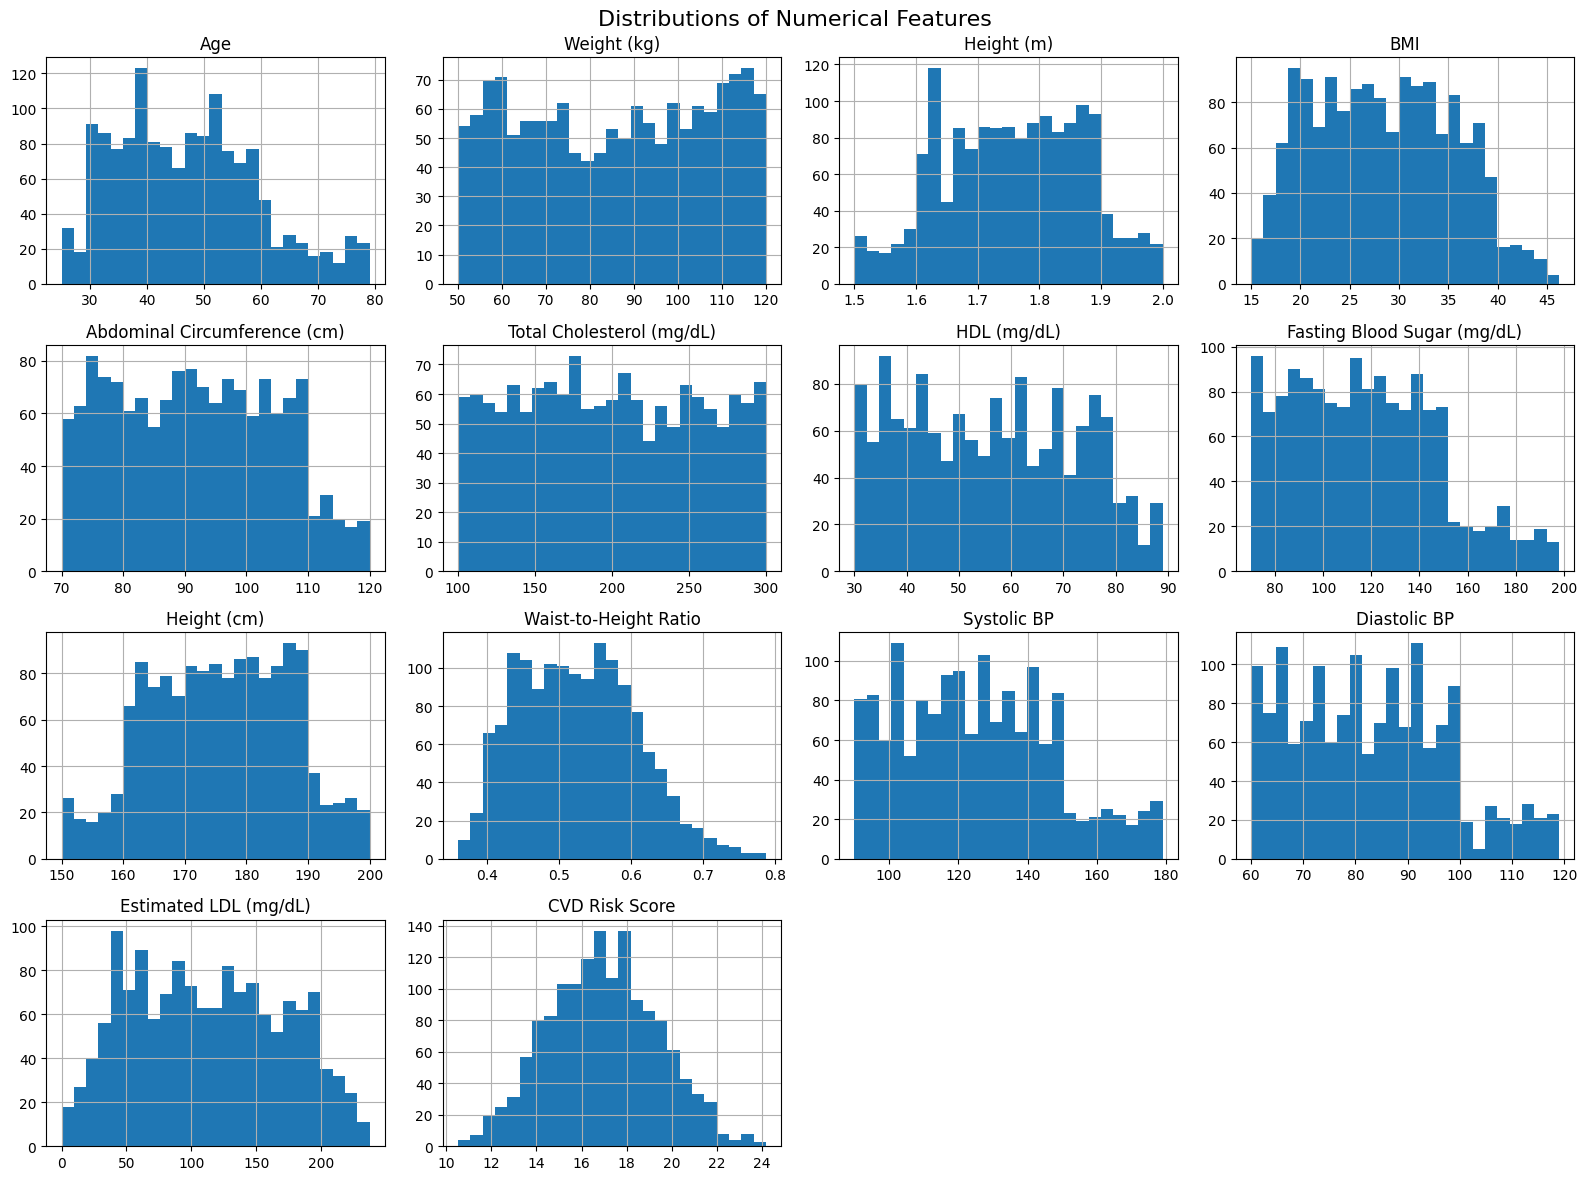

In [ ]:
numeric_cols = data.select_dtypes(include=np.number).columns.tolist()
display(data[numeric_cols].describe().T)

# Histograms
data[numeric_cols].hist(figsize=(16, 12), bins=25)
plt.suptitle("Distributions of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

# EDA (Categorical Features and Targets)


Sex


,count
Sex,
F,773
M,756



Blood Pressure (mmHg)


,count
Blood Pressure (mmHg),
113/77,4
114/63,4
127/84,4
113/79,4
148/98,3
...,...
120/97,1
93/73,1
96/71,1



Smoking Status


...

,count
Family History of CVD,
N,780
Y,749



Blood Pressure Category


,count
Blood Pressure Category,
Hypertension Stage 2,632
Hypertension Stage 1,497
Normal,300
Elevated,100



CVD Risk Level


,count
CVD Risk Level,
HIGH,728
INTERMEDIARY,581
LOW,220


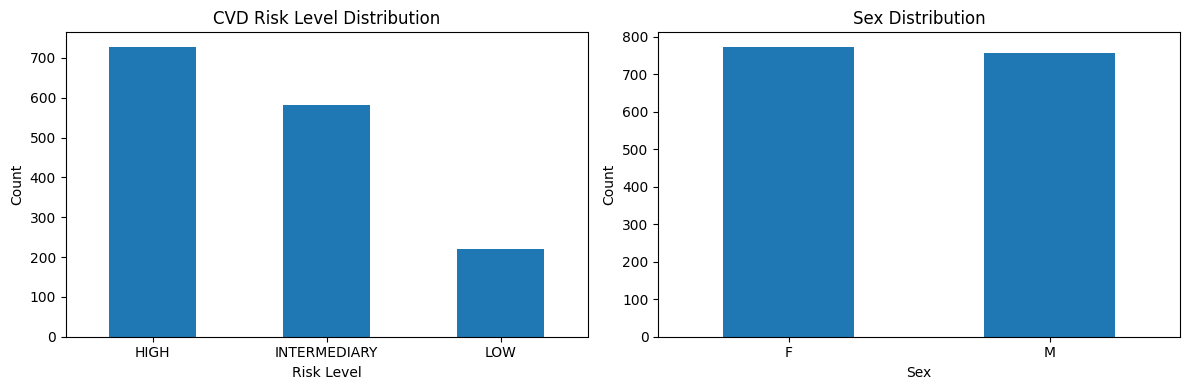

In [ ]:
categorical_cols = data.select_dtypes(exclude=np.number).columns.tolist()

for col in categorical_cols:
    print(f"\n{col}")
    display(data[col].value_counts(dropna=False).to_frame("count"))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

data["CVD Risk Level"].value_counts().plot(kind="bar", ax=axes[0])
axes[0].set_title("CVD Risk Level Distribution")
axes[0].set_xlabel("Risk Level")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)

data["Sex"].value_counts().plot(kind="bar", ax=axes[1])
axes[1].set_title("Sex Distribution")
axes[1].set_xlabel("Sex")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

# EDA Correlation with the Numerical Target

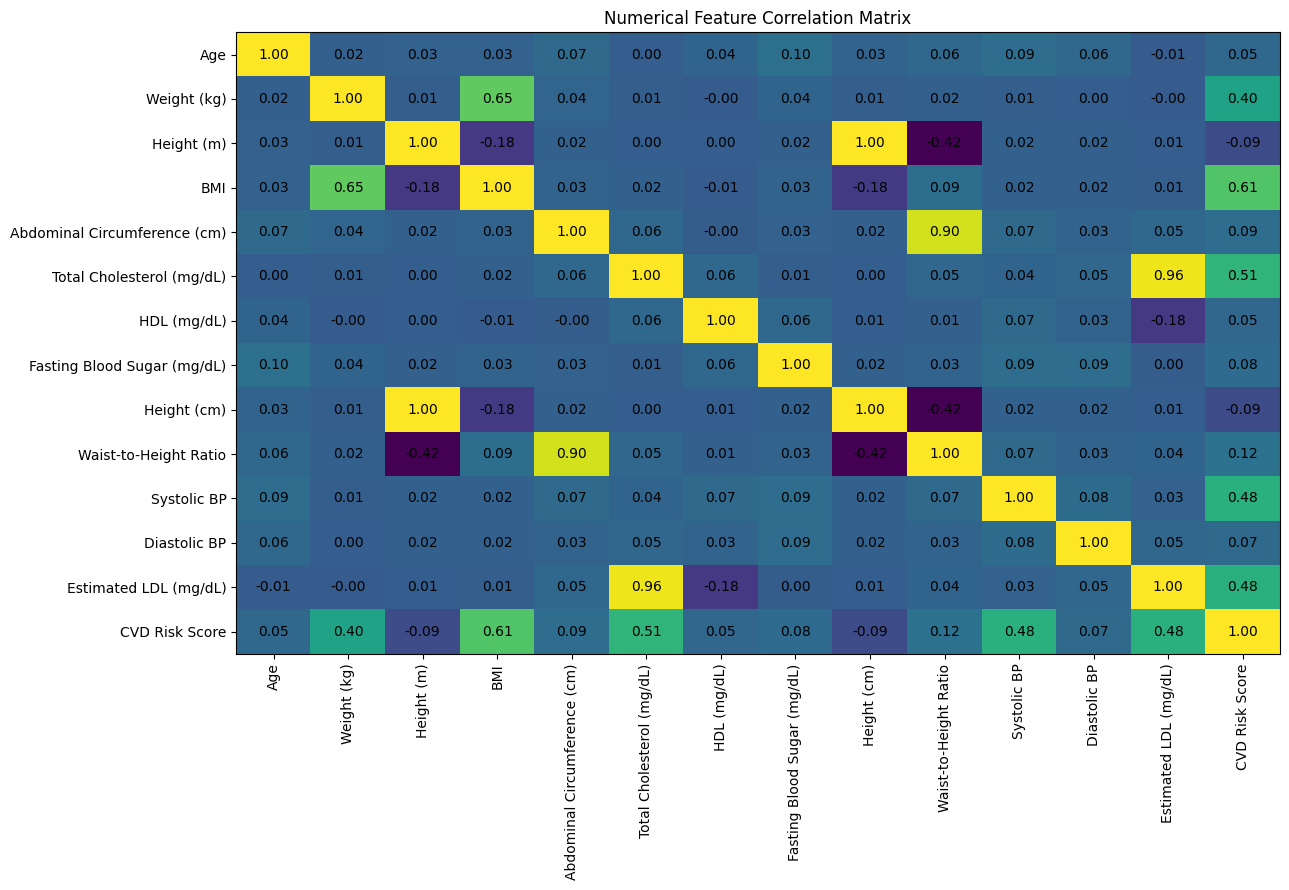

In [ ]:
corr = data[numeric_cols].corr(numeric_only=True)

plt.figure(figsize=(13, 9))
plt.imshow(corr, aspect="auto")

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)

# Add correlation values [each cell]
for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        plt.text(
            j, i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Numerical Feature Correlation Matrix")
plt.tight_layout()
plt.show()

# Training Testing

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_cls,
    test_size=0.20,
    random_state=42,
    stratify=y_cls
)

print("Training set shape:", X_train.shape)
print("Testing set shape :", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training set shape: (1223, 18)
Testing set shape : (306, 18)

Training target distribution:
CVD Risk Level
HIGH            582
INTERMEDIARY    465
LOW             176
Name: count, dtype: int64

Testing target distribution:
CVD Risk Level
HIGH            146
INTERMEDIARY    116
LOW              44
Name: count, dtype: int64


In [ ]:

numeric_features = X_train.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X_train.select_dtypes(
    exclude=np.number
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['Age', 'Weight (kg)', 'Height (m)', 'BMI', 'Abdominal Circumference (cm)', 'Total Cholesterol (mg/dL)', 'HDL (mg/dL)', 'Fasting Blood Sugar (mg/dL)', 'Waist-to-Height Ratio', 'Systolic BP', 'Diastolic BP', 'Estimated LDL (mg/dL)']

Categorical features:
['Sex', 'Smoking Status', 'Diabetes Status', 'Physical Activity Level', 'Family History of CVD', 'Blood Pressure Category']


In [ ]:


numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# Logistic Regression

In [ ]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

logistic_model.fit(X_train, y_train)

y_pred = logistic_model.predict(X_test)

print("Predictions:")
print(y_pred[:20])

Predictions:
['INTERMEDIARY' 'INTERMEDIARY' 'INTERMEDIARY' 'HIGH' 'HIGH' 'INTERMEDIARY'
 'HIGH' 'HIGH' 'INTERMEDIARY' 'HIGH' 'INTERMEDIARY' 'INTERMEDIARY'
 'INTERMEDIARY' 'HIGH' 'HIGH' 'INTERMEDIARY' 'HIGH' 'INTERMEDIARY' 'HIGH'
 'INTERMEDIARY']


In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.6535947712418301

Classification Report:
              precision    recall  f1-score   support

        HIGH       0.71      0.75      0.73       146
INTERMEDIARY       0.63      0.74      0.68       116
         LOW       0.31      0.09      0.14        44

    accuracy                           0.65       306
   macro avg       0.55      0.53      0.52       306
weighted avg       0.62      0.65      0.63       306



# Random Forest

In [ ]:
import numpy as np

# Fit preprocessing only on training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform test data using the same preprocessor
X_test_processed = preprocessor.transform(X_test)

# Convert to NumPy arrays
if hasattr(X_train_processed, "toarray"):
    X_train_np = X_train_processed.toarray()
else:
    X_train_np = np.asarray(X_train_processed)

if hasattr(X_test_processed, "toarray"):
    X_test_np = X_test_processed.toarray()
else:
    X_test_np = np.asarray(X_test_processed)

y_train_np = np.asarray(y_train)
y_test_np = np.asarray(y_test)

print("Training shape:", X_train_np.shape)
print("Testing shape :", X_test_np.shape)

Training shape: (1223, 27)
Testing shape : (306, 27)


In [ ]:
import numpy as np

from sklearn.tree import DecisionTreeClassifier


class RandomForest:
    def __init__(
        self,
        n_estimators=100,
        max_depth=None,
        random_state=42
    ):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.random_state = random_state

        # Store all Decision Trees
        self.trees = []

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y)

        n_samples = X.shape[0]

        random_generator = np.random.default_rng(
            self.random_state
        )

        self.trees = []

        # Create the requested number of trees
        for tree_number in range(self.n_estimators):

            # Create bootstrap sample indices
            sample_indices = random_generator.choice(
                n_samples,
                size=n_samples,
                replace=True
            )

            # Create bootstrap training sample
            X_sample = X[sample_indices]
            y_sample = y[sample_indices]

            # Create one Decision Tree
            tree = DecisionTreeClassifier(
                max_depth=self.max_depth,

                # Each split uses random features
                max_features="sqrt",

                random_state=(
                    self.random_state + tree_number
                )
            )

            # Train the tree
            tree.fit(
                X_sample,
                y_sample
            )

            # Store the trained tree
            self.trees.append(tree)

        return self

    def predict(self, X):
        X = np.asarray(X, dtype=float)

        if len(self.trees) == 0:
            raise ValueError(
                "The Random Forest has not been trained."
            )

        # Collect predictions from every tree
        all_predictions = np.array([
            tree.predict(X)
            for tree in self.trees
        ])

        final_predictions = []

        # Apply majority voting to each test row
        for sample_predictions in all_predictions.T:

            classes, counts = np.unique(
                sample_predictions,
                return_counts=True
            )

            majority_class = classes[
                np.argmax(counts)
            ]

            final_predictions.append(
                majority_class
            )

        return np.asarray(final_predictions)

In [ ]:
# Create the Random Forest object
random_forest = RandomForest(
    n_estimators=25,
    max_depth=5,
    random_state=42
)

# Train it using the existing training data
random_forest.fit(
    X_train_np,
    y_train_np
)

print("Random Forest training completed.")
print("Number of trees:", len(random_forest.trees))

y_pred_rf_scr = random_forest.predict(
    X_test_np
)

print("First 20 predictions:")
print(y_pred_rf_scr[:20])

Random Forest training completed.
Number of trees: 25
First 20 predictions:
['INTERMEDIARY' 'INTERMEDIARY' 'INTERMEDIARY' 'HIGH' 'INTERMEDIARY'
 'INTERMEDIARY' 'HIGH' 'HIGH' 'INTERMEDIARY' 'INTERMEDIARY' 'INTERMEDIARY'
 'INTERMEDIARY' 'INTERMEDIARY' 'HIGH' 'HIGH' 'HIGH' 'HIGH' 'HIGH'
 'INTERMEDIARY' 'INTERMEDIARY']


In [ ]:
from sklearn.metrics import accuracy_score

accuracy_rf_scr = accuracy_score(
    y_test_np,
    y_pred_rf_scr
)

error_rf_scr = 1 - accuracy_rf_scr

print(
    "Random Forest Classifier Accuracy:",
    accuracy_rf_scr
)

Random Forest Classifier Accuracy: 0.5882352941176471


In [ ]:
from sklearn.metrics import classification_report

print("Classification Report:")

print(
    classification_report(
        y_test_np,
        y_pred_rf_scr
    )
)

Classification Report:
              precision    recall  f1-score   support

        HIGH       0.61      0.74      0.67       146
INTERMEDIARY       0.56      0.62      0.59       116
         LOW       0.00      0.00      0.00        44

    accuracy                           0.59       306
   macro avg       0.39      0.45      0.42       306
weighted avg       0.50      0.59      0.54       306



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Adaboost Classifier

In [ ]:
import numpy as np

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [ ]:
import numpy as np

from sklearn.tree import DecisionTreeClassifier


class AdaBoostClassifierScratch:
    def __init__(
        self,
        n_estimators=50,
        learning_rate=1.0,
        random_state=42
    ):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.random_state = random_state

        self.models = []
        self.alphas = []
        self.classes_ = None

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y)

        self.classes_ = np.unique(y)

        n_samples = X.shape[0]
        n_classes = len(self.classes_)

        # Initially, all samples have equal weights
        weights = np.ones(n_samples) / n_samples

        self.models = []
        self.alphas = []

        for estimator in range(self.n_estimators):

            # Create a Decision Stump
            stump = DecisionTreeClassifier(
                max_depth=1,
                random_state=self.random_state + estimator
            )

            # Train using the current sample weights
            stump.fit(
                X,
                y,
                sample_weight=weights
            )

            # Predict training data
            predictions = stump.predict(X)

            incorrect = predictions != y

            # Calculate weighted error
            error = np.sum(
                weights * incorrect
            )

            error = np.clip(
                error,
                1e-10,
                1 - 1e-10
            )

            # For three classes, error must be below 2/3
            maximum_error = 1 - (1 / n_classes)

            if error >= maximum_error:
                break

            # SAMME amount-of-say formula
            alpha = self.learning_rate * (
                np.log((1 - error) / error)
                + np.log(n_classes - 1)
            )

            self.models.append(stump)
            self.alphas.append(alpha)

            # Increase weights of incorrect samples
            weights *= np.exp(
                alpha * incorrect
            )

            # Normalize weights
            weights /= np.sum(weights)

        return self

    def predict(self, X):
        X = np.asarray(X, dtype=float)

        if len(self.models) == 0:
            raise ValueError(
                "AdaBoost did not train any valid stumps."
            )

        # Score for each class
        class_scores = np.zeros(
            (X.shape[0], len(self.classes_))
        )

        for alpha, stump in zip(
            self.alphas,
            self.models
        ):
            predictions = stump.predict(X)

            for class_index, class_label in enumerate(
                self.classes_
            ):
                class_scores[:, class_index] += (
                    alpha
                    * (predictions == class_label)
                )

        best_class_indices = np.argmax(
            class_scores,
            axis=1
        )

        return self.classes_[best_class_indices]

In [ ]:
adaboost = AdaBoostClassifierScratch(
    n_estimators=50,
    learning_rate=1.0,
    random_state=42
)

adaboost.fit(
    X_train_np,
    y_train_np
)

print("AdaBoost training completed.")
print("Trained stumps:", len(adaboost.models))

y_pred_ab = adaboost.predict(
    X_test_np
)

print("First 20 predictions:")
print(y_pred_ab[:20])

AdaBoost training completed.
Trained stumps: 50
First 20 predictions:
['INTERMEDIARY' 'INTERMEDIARY' 'INTERMEDIARY' 'HIGH' 'INTERMEDIARY' 'HIGH'
 'HIGH' 'HIGH' 'INTERMEDIARY' 'HIGH' 'INTERMEDIARY' 'INTERMEDIARY'
 'INTERMEDIARY' 'HIGH' 'HIGH' 'HIGH' 'INTERMEDIARY' 'INTERMEDIARY'
 'INTERMEDIARY' 'INTERMEDIARY']


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

accuracy_ab = accuracy_score(
    y_test_np,
    y_pred_ab
)

error_ab = 1 - accuracy_ab

print("AdaBoost Accuracy:", accuracy_ab)
print("AdaBoost Error:", error_ab)

print("\nClassification Report:")
print(
    classification_report(
        y_test_np,
        y_pred_ab
    )
)

AdaBoost Accuracy: 0.6437908496732027
AdaBoost Error: 0.35620915032679734

Classification Report:
              precision    recall  f1-score   support

        HIGH       0.66      0.77      0.71       146
INTERMEDIARY       0.63      0.73      0.68       116
         LOW       0.00      0.00      0.00        44

    accuracy                           0.64       306
   macro avg       0.43      0.50      0.46       306
weighted avg       0.56      0.64      0.60       306



In [ ]:
from sklearn.model_selection import train_test_split

X_nn_train, X_nn_val, y_nn_train, y_nn_val = train_test_split(
    X_train,
    y_train,
    train_size=0.875,  # 70/80 = 0.875
    random_state=42,
    stratify=y_train
)

print("Training shape  :", X_nn_train.shape)
print("Validation shape:", X_nn_val.shape)
print("Testing shape   :", X_test.shape)

Training shape  : (1070, 18)
Validation shape: (153, 18)
Testing shape   : (306, 18)


# Neural Networks

In [ ]:
import numpy as np

from sklearn.base import clone

nn_preprocessor = clone(preprocessor)

# Fit only on the 70% training data
X_nn_train_np = nn_preprocessor.fit_transform(
    X_nn_train
)

X_nn_val_np = nn_preprocessor.transform(
    X_nn_val
)

X_nn_test_np = nn_preprocessor.transform(
    X_test
)

# Convert sparse matrices to arrays
if hasattr(X_nn_train_np, "toarray"):
    X_nn_train_np = X_nn_train_np.toarray()
    X_nn_val_np = X_nn_val_np.toarray()
    X_nn_test_np = X_nn_test_np.toarray()

print("Processed training shape  :", X_nn_train_np.shape)
print("Processed validation shape:", X_nn_val_np.shape)
print("Processed testing shape   :", X_nn_test_np.shape)

Processed training shape  : (1070, 27)
Processed validation shape: (153, 27)
Processed testing shape   : (306, 27)


In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder_nn = LabelEncoder()

y_nn_train_encoded = label_encoder_nn.fit_transform(
    y_nn_train
)

y_nn_val_encoded = label_encoder_nn.transform(
    y_nn_val
)

y_nn_test_encoded = label_encoder_nn.transform(
    y_test
)

print("Classes:", label_encoder_nn.classes_)

Classes: ['HIGH' 'INTERMEDIARY' 'LOW']


In [ ]:
import tensorflow as tf

tf.random.set_seed(42)

neural_network = tf.keras.Sequential([
    tf.keras.layers.Input(
        shape=(X_nn_train_np.shape[1],)
    ),

    # Hidden layer
    tf.keras.layers.Dense(
        32,
        activation="relu"
    ),

    # Output layer: one neuron for each class
    tf.keras.layers.Dense(
        3,
        activation="softmax"
    )
])

neural_network.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

neural_network.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 32)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 995 (3.89 KB)

 Trainable params: 995 (3.89 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = neural_network.fit(
    X_nn_train_np,
    y_nn_train_encoded,

    validation_data=(
        X_nn_val_np,
        y_nn_val_encoded
    ),

    epochs=100,
    batch_size=32,
    verbose=1
)

Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4019 - loss: 1.1627 - val_accuracy: 0.5490 - val_loss: 0.9805
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5056 - loss: 1.0044 - val_accuracy: 0.6013 - val_loss: 0.9153
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5421 - loss: 0.9486 - val_accuracy: 0.6078 - val_loss: 0.8875
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5673 - loss: 0.9121 - val_accuracy: 0.6340 - val_loss: 0.8670
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5916 - loss: 0.8829 - val_accuracy: 0.6078 - val_loss: 0.8510
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6215 - loss: 0.8586 - val_accuracy: 0.6144 - val_loss: 0.8391
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6411 - loss: 0.8384 - val_accuracy: 0.6340 - val_loss: 0.8294
Epoch 8/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6458 - loss: 0.8214 - val_accuracy: 0.6340 - v

In [ ]:
test_loss, test_accuracy = neural_network.evaluate(
    X_nn_test_np,
    y_nn_test_encoded,
    verbose=0
)

test_error = 1 - test_accuracy

print("Neural Network Test Accuracy:", test_accuracy)

Neural Network Test Accuracy: 0.6274510025978088


In [ ]:
# Get class probabilities
prediction_probabilities = neural_network.predict(
    X_nn_test_np
)

# Select the class with the highest probability
y_pred_nn_encoded = np.argmax(
    prediction_probabilities,
    axis=1
)

# Convert numbers back to original class names
y_pred_nn = label_encoder_nn.inverse_transform(
    y_pred_nn_encoded
)

print("First 20 predictions:")
print(y_pred_nn[:20])

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
First 20 predictions:
['INTERMEDIARY' 'INTERMEDIARY' 'INTERMEDIARY' 'HIGH' 'HIGH' 'INTERMEDIARY'
 'HIGH' 'HIGH' 'INTERMEDIARY' 'HIGH' 'INTERMEDIARY' 'INTERMEDIARY' 'HIGH'
 'HIGH' 'HIGH' 'INTERMEDIARY' 'HIGH' 'LOW' 'HIGH' 'INTERMEDIARY']


In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

print("Classification Report:")

print(
    classification_report(
        y_test,
        y_pred_nn
    )
)

Classification Report:
              precision    recall  f1-score   support

        HIGH       0.70      0.71      0.71       146
INTERMEDIARY       0.60      0.67      0.64       116
         LOW       0.36      0.23      0.28        44

    accuracy                           0.63       306
   macro avg       0.55      0.54      0.54       306
weighted avg       0.61      0.63      0.62       306



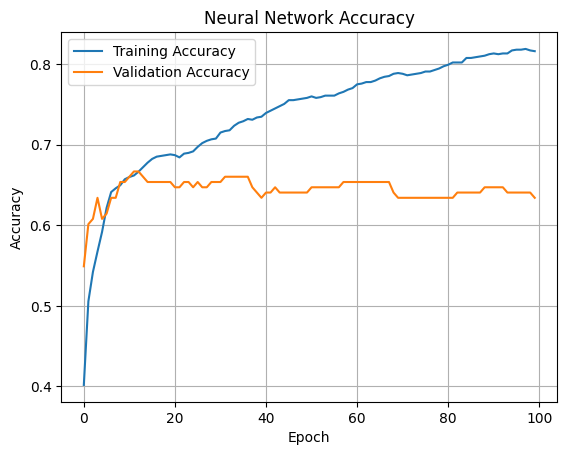

In [ ]:
import matplotlib.pyplot as plt

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Neural Network Accuracy")
plt.legend()
plt.grid()
plt.show()

# PCA for Dimensionality Reduction

In [ ]:
from sklearn.decomposition import PCA

# Fit PCA on the training data only, then transform train/test
pca = PCA(n_components=0.95, random_state=42)

X_train_pca = pca.fit_transform(X_train_np)
X_test_pca = pca.transform(X_test_np)

print("Original feature count (after preprocessing):", X_train_np.shape[1])
print("Components kept (95% variance):", pca.n_components_)
print("Total variance explained:", pca.explained_variance_ratio_.sum())

Original feature count (after preprocessing): 27
Components kept (95% variance): 16
Total variance explained: 0.9604452889534512


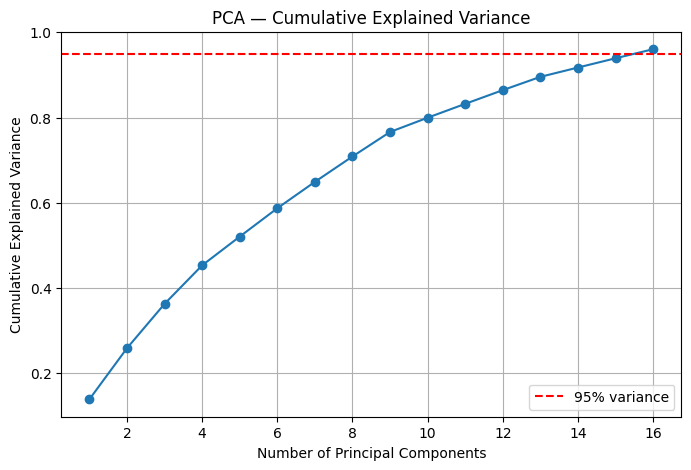

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker="o")
plt.axhline(y=0.95, color="r", linestyle="--", label="95% variance")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA — Cumulative Explained Variance")
plt.legend()
plt.grid()
plt.show()

# Re-training the Existing Models on PCA Data

In [ ]:
# Logistic Regression on PCA data
logistic_model_pca = LogisticRegression(max_iter=1000, random_state=42)
logistic_model_pca.fit(X_train_pca, y_train_np)

y_pred_lr_pca = logistic_model_pca.predict(X_test_pca)
accuracy_lr_pca = accuracy_score(y_test_np, y_pred_lr_pca)

print("Logistic Regression (PCA) Accuracy:", accuracy_lr_pca)

Logistic Regression (PCA) Accuracy: 0.6470588235294118


In [ ]:
# Random Forest (scratch) on PCA data
random_forest_pca = RandomForest(n_estimators=25, max_depth=5, random_state=42)
random_forest_pca.fit(X_train_pca, y_train_np)

y_pred_rf_pca = random_forest_pca.predict(X_test_pca)
accuracy_rf_pca = accuracy_score(y_test_np, y_pred_rf_pca)

print("Random Forest (PCA) Accuracy:", accuracy_rf_pca)

Random Forest (PCA) Accuracy: 0.5947712418300654


In [ ]:
# AdaBoost (scratch) on PCA data
adaboost_pca = AdaBoostClassifierScratch(n_estimators=50, learning_rate=1.0, random_state=42)
adaboost_pca.fit(X_train_pca, y_train_np)

y_pred_ab_pca = adaboost_pca.predict(X_test_pca)
accuracy_ab_pca = accuracy_score(y_test_np, y_pred_ab_pca)

print("AdaBoost (PCA) Accuracy:", accuracy_ab_pca)

AdaBoost (PCA) Accuracy: 0.6078431372549019


In [ ]:
# Transform the NN's train/val/test splits with the already-fitted PCA
X_nn_train_pca = pca.transform(X_nn_train_np)
X_nn_val_pca = pca.transform(X_nn_val_np)
X_nn_test_pca = pca.transform(X_nn_test_np)

print("NN PCA training shape:", X_nn_train_pca.shape)

NN PCA training shape: (1070, 16)


In [ ]:
tf.random.set_seed(42)

neural_network_pca = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_nn_train_pca.shape[1],)),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(3, activation="softmax")
])

neural_network_pca.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_pca = neural_network_pca.fit(
    X_nn_train_pca, y_nn_train_encoded,
    validation_data=(X_nn_val_pca, y_nn_val_encoded),
    epochs=100, batch_size=32, verbose=0
)

_, test_accuracy_pca = neural_network_pca.evaluate(X_nn_test_pca, y_nn_test_encoded, verbose=0)

print("Neural Network (PCA) Test Accuracy:", test_accuracy_pca)

Neural Network (PCA) Test Accuracy: 0.6045751571655273


In [ ]:
print("Before vs. After PCA — Accuracy Comparison:\n")

pca_comparison = {
    "Logistic Regression": (accuracy, accuracy_lr_pca),
    "Random Forest":       (accuracy_rf_scr, accuracy_rf_pca),
    "AdaBoost":             (accuracy_ab, accuracy_ab_pca),
    "Neural Network":       (test_accuracy, test_accuracy_pca)
}

for name, (before, after) in pca_comparison.items():
    change = (after - before) * 100
    direction = "improved" if change > 0 else ("dropped" if change < 0 else "unchanged")
    print(
        f"{name:20s} before: {before*100:6.2f}%   "
        f"after: {after*100:6.2f}%   ({direction} by {abs(change):.2f} pts)"
    )

Before vs. After PCA — Accuracy Comparison:

Logistic Regression  before:  65.36%   after:  64.71%   (dropped by 0.65 pts)
Random Forest        before:  58.82%   after:  59.48%   (improved by 0.65 pts)
AdaBoost             before:  64.38%   after:  60.78%   (dropped by 3.59 pts)
Neural Network       before:  62.75%   after:  60.46%   (dropped by 2.29 pts)


# KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(
    n_neighbors=15,
    weights="distance"
)

knn_model.fit(X_train_pca, y_train_np)

KNeighborsClassifier(n_neighbors=15, weights='distance')

In [ ]:
y_pred_knn = knn_model.predict(X_test_pca)

accuracy_knn = accuracy_score(y_test_np, y_pred_knn)
error_knn = 1 - accuracy_knn

print("KNN Accuracy:", accuracy_knn)

print("\nClassification Report:")
print(classification_report(y_test_np, y_pred_knn))

KNN Accuracy: 0.5980392156862745

Classification Report:
              precision    recall  f1-score   support

        HIGH       0.62      0.75      0.68       146
INTERMEDIARY       0.58      0.62      0.60       116
         LOW       0.25      0.02      0.04        44

    accuracy                           0.60       306
   macro avg       0.48      0.47      0.44       306
weighted avg       0.55      0.60      0.56       306



# Gradient Boosting Classifier

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train_pca, y_train_np)

GradientBoostingClassifier(random_state=42)

In [ ]:
y_pred_gb = gb_model.predict(X_test_pca)

accuracy_gb = accuracy_score(y_test_np, y_pred_gb)

print("Gradient Boosting Accuracy:", accuracy_gb)

print("\nClassification Report:")
print(classification_report(y_test_np, y_pred_gb))

Gradient Boosting Accuracy: 0.6503267973856209

Classification Report:
              precision    recall  f1-score   support

        HIGH       0.71      0.76      0.73       146
INTERMEDIARY       0.64      0.71      0.67       116
         LOW       0.29      0.14      0.18        44

    accuracy                           0.65       306
   macro avg       0.54      0.53      0.53       306
weighted avg       0.62      0.65      0.63       306



# Regression Model

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

reg_mask = y_reg.notna()
print("Rows dropped for missing CVD Risk Score:", (~reg_mask).sum())

X_reg_clean = X.loc[reg_mask]
y_reg_clean = y_reg.loc[reg_mask]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg_clean,
    y_reg_clean,
    test_size=0.20,
    random_state=42
)

print("Training set shape:", X_train_reg.shape)
print("Testing set shape :", X_test_reg.shape)

Rows dropped for missing CVD Risk Score: 70
Training set shape: (1167, 18)
Testing set shape : (292, 18)


In [ ]:
regression_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", RandomForestRegressor(
            n_estimators=200,
            max_depth=8,
            random_state=42
        ))
    ]
)

regression_model.fit(X_train_reg, y_train_reg)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Weight (kg)',
                                                   'Height (m)', 'BMI',
                                                   'Abdominal Circumference '
                                                   '(cm)',
                                                   'Total Cholesterol (mg/dL)',
                                                   'HDL (mg/dL)',
                                                   'Fasting Blood Sugar '
                                                   '(mg/dL)',
                                                   'Waist-to-Height Ratio',
                                                   'Systolic BP',
                                                   'Diastolic BP',
                                                   'Estimated LDL (mg/dL)']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Sex', 'Smoking Status',
                                                   'Diabetes Status',
                                                   'Physical Activity Level',
                                                   'Family History of CVD',
                                                   'Blood Pressure '
                                                   'Category'])])),
                ('regressor',
                 RandomForestRegressor(max_depth=8, n_estimators=200,
                                       random_state=42))])

In [ ]:
y_pred_reg = regression_model.predict(X_test_reg)

mae = mean_absolute_error(y_test_reg, y_pred_reg)
rmse = mean_squared_error(y_test_reg, y_pred_reg) ** 0.5
r2 = r2_score(y_test_reg, y_pred_reg)

print("Regression Results (CVD Risk Score):")
print("MAE :", mae)
print("RMSE:", rmse)
print("R^2 :", r2)

Regression Results (CVD Risk Score):
MAE : 0.40789691597152866
RMSE: 0.5437173105722288
R^2 : 0.9509775671815479


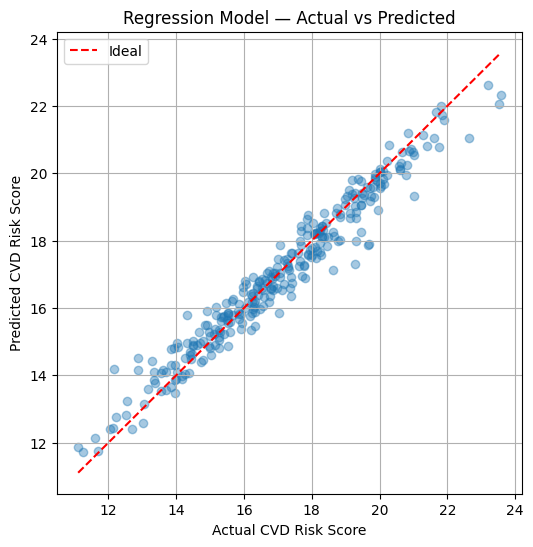

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(y_test_reg, y_pred_reg, alpha=0.4)
min_val = min(y_test_reg.min(), y_pred_reg.min())
max_val = max(y_test_reg.max(), y_pred_reg.max())
plt.plot([min_val, max_val], [min_val, max_val], "r--", label="Ideal")
plt.xlabel("Actual CVD Risk Score")
plt.ylabel("Predicted CVD Risk Score")
plt.title("Regression Model — Actual vs Predicted")
plt.legend()
plt.grid()
plt.show()

In [ ]:
model_accuracies = {
    "Logistic Regression": accuracy,
    "Random Forest": accuracy_rf_scr,
    "AdaBoost": accuracy_ab,
    "Neural Network": test_accuracy,
    "KNN (PCA)": accuracy_knn,
    "Gradient Boosting (PCA)": accuracy_gb
}

print("Test Accuracy Comparison:\n")

for model_name, model_accuracy in model_accuracies.items():
    print(
        f"{model_name}: {model_accuracy * 100:.2f}%"
    )

best_model = max(
    model_accuracies,
    key=model_accuracies.get
)

print("\nBest Model:", best_model)

print(
    "Best Test Accuracy:",
    f"{model_accuracies[best_model] * 100:.2f}%"
)

print("\nRegression (CVD Risk Score) R^2:", r2)

Test Accuracy Comparison:

Logistic Regression: 65.36%
Random Forest: 58.82%
AdaBoost: 64.38%
Neural Network: 62.75%
KNN (PCA): 59.80%
Gradient Boosting (PCA): 65.03%

Best Model: Logistic Regression
Best Test Accuracy: 65.36%

Regression (CVD Risk Score) R^2: 0.9509775671815479


# Evaluation

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

CLASS_NAMES = np.array([
    "HIGH",
    "INTERMEDIARY",
    "LOW"
])


# Neural Network prediction after PCA
probability_nn_pca = neural_network_pca.predict(
    X_nn_test_pca,
    verbose=0
)

y_pred_nn_pca_encoded = np.argmax(
    probability_nn_pca,
    axis=1
)

y_pred_nn_pca = label_encoder_nn.inverse_transform(
    y_pred_nn_pca_encoded
)


# Models before PCA
before_pca_predictions = {
    "Logistic Regression": y_pred,
    "Random Forest": y_pred_rf_scr,
    "AdaBoost": y_pred_ab,
    "Neural Network": y_pred_nn
}


# Models after PCA
after_pca_predictions = {
    "Logistic Regression": y_pred_lr_pca,
    "Random Forest": y_pred_rf_pca,
    "AdaBoost": y_pred_ab_pca,
    "Neural Network": y_pred_nn_pca,
    "KNN": y_pred_knn,
    "Gradient Boosting": y_pred_gb
}

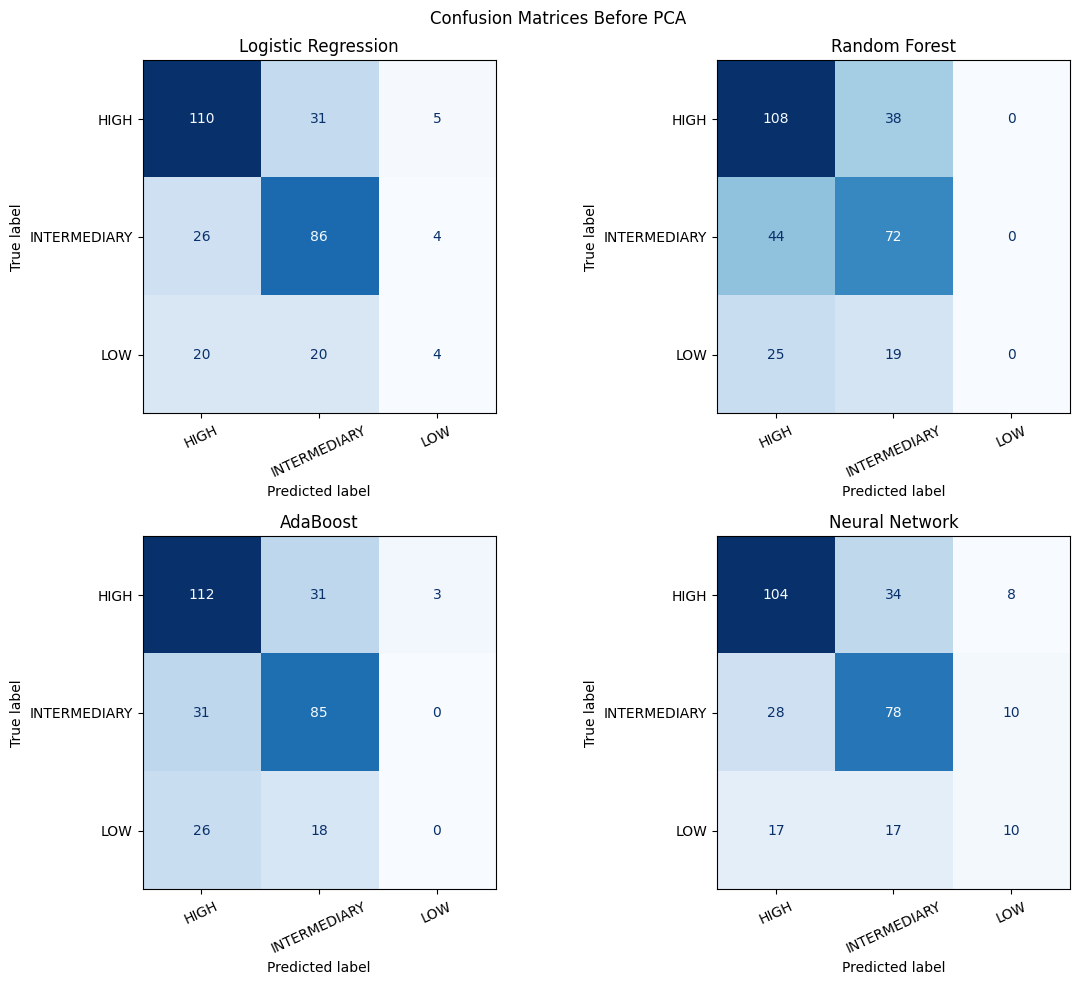

In [ ]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 10)
)

axes = axes.flatten()

for ax, (model_name, prediction) in zip(
    axes,
    before_pca_predictions.items()
):

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        prediction,
        labels=CLASS_NAMES,
        display_labels=CLASS_NAMES,
        cmap="Blues",
        colorbar=False,
        ax=ax
    )

    ax.set_title(model_name)
    ax.tick_params(axis="x", rotation=25)

plt.suptitle("Confusion Matrices Before PCA")
plt.tight_layout()
plt.show()

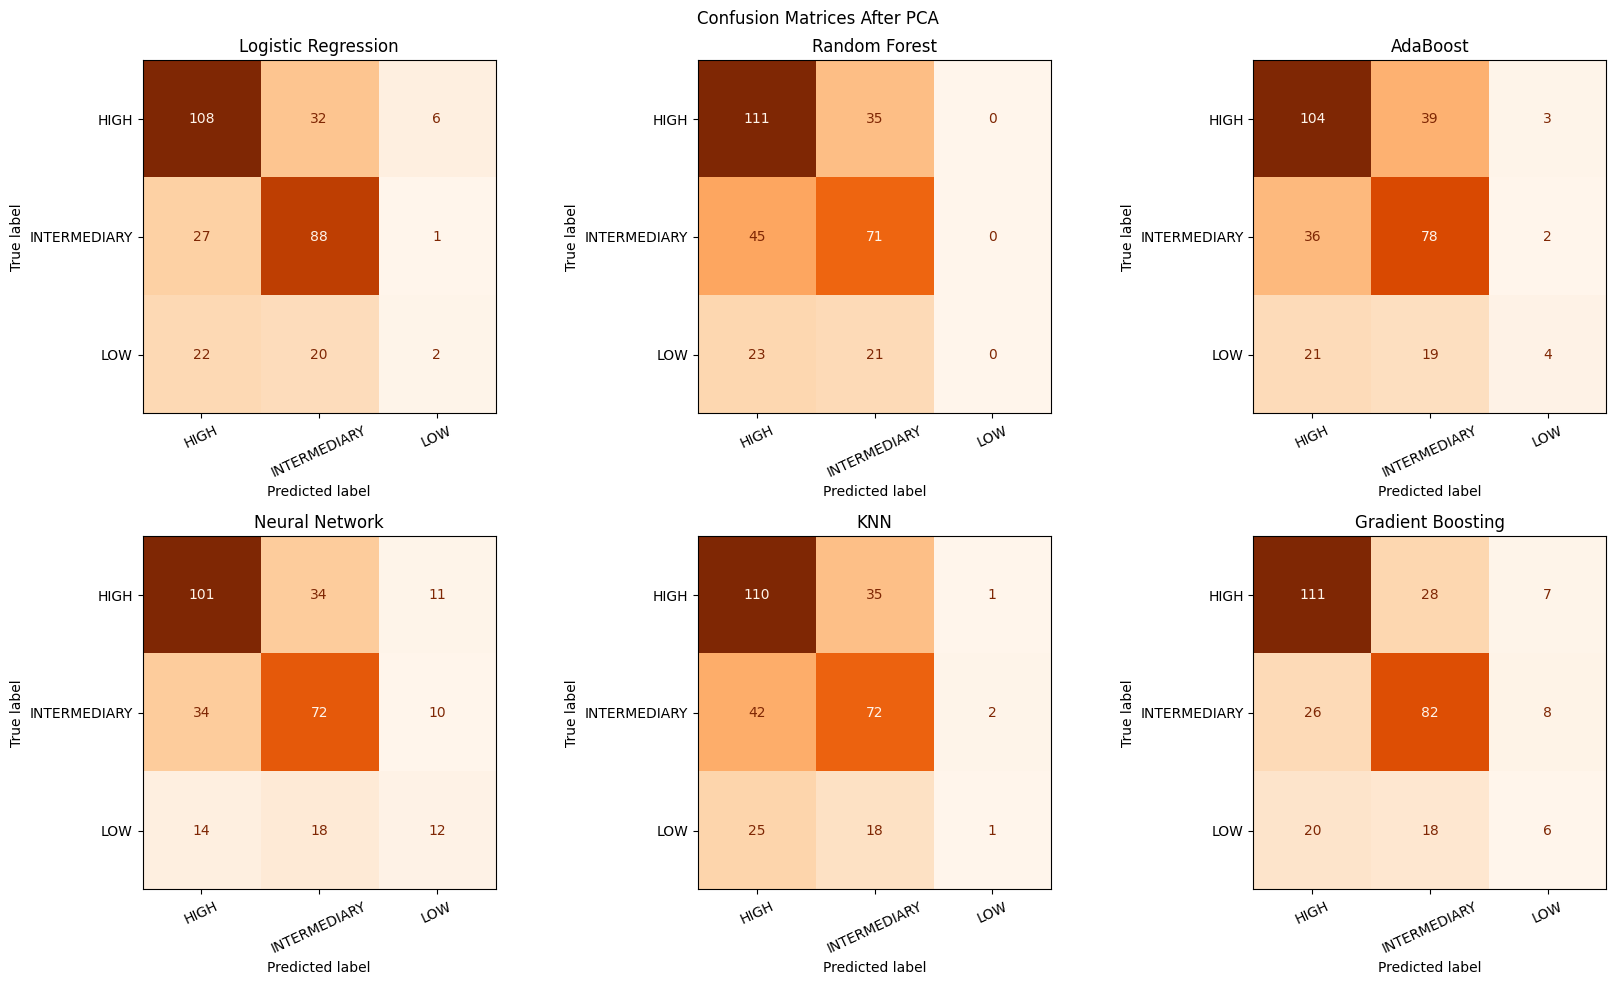

In [ ]:
fig, axes = plt.subplots(
    2,
    3,
    figsize=(17, 10)
)

axes = axes.flatten()

for ax, (model_name, prediction) in zip(
    axes,
    after_pca_predictions.items()
):

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        prediction,
        labels=CLASS_NAMES,
        display_labels=CLASS_NAMES,
        cmap="Oranges",
        colorbar=False,
        ax=ax
    )

    ax.set_title(model_name)
    ax.tick_params(axis="x", rotation=25)

plt.suptitle("Confusion Matrices After PCA")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.base import clone
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, roc_auc_score

# Logistic Regression before PCA
lr_before = clone(logistic_model)

lr_before.fit(
    X_train,
    y_train
)

# Classes converted into 0 and 1 format for ROC
y_test_binary = label_binarize(
    y_test,
    classes=CLASS_NAMES
)

roc_models = {
    "Logistic Regression — Before PCA":
        lr_before.predict_proba(X_test),

    "Neural Network — Before PCA":
        prediction_probabilities,

    "Logistic Regression — After PCA":
        logistic_model_pca.predict_proba(X_test_pca),

    "Neural Network — After PCA":
        probability_nn_pca,

    "KNN — After PCA":
        knn_model.predict_proba(X_test_pca),

    "Gradient Boosting — After PCA":
        gb_model.predict_proba(X_test_pca)
}

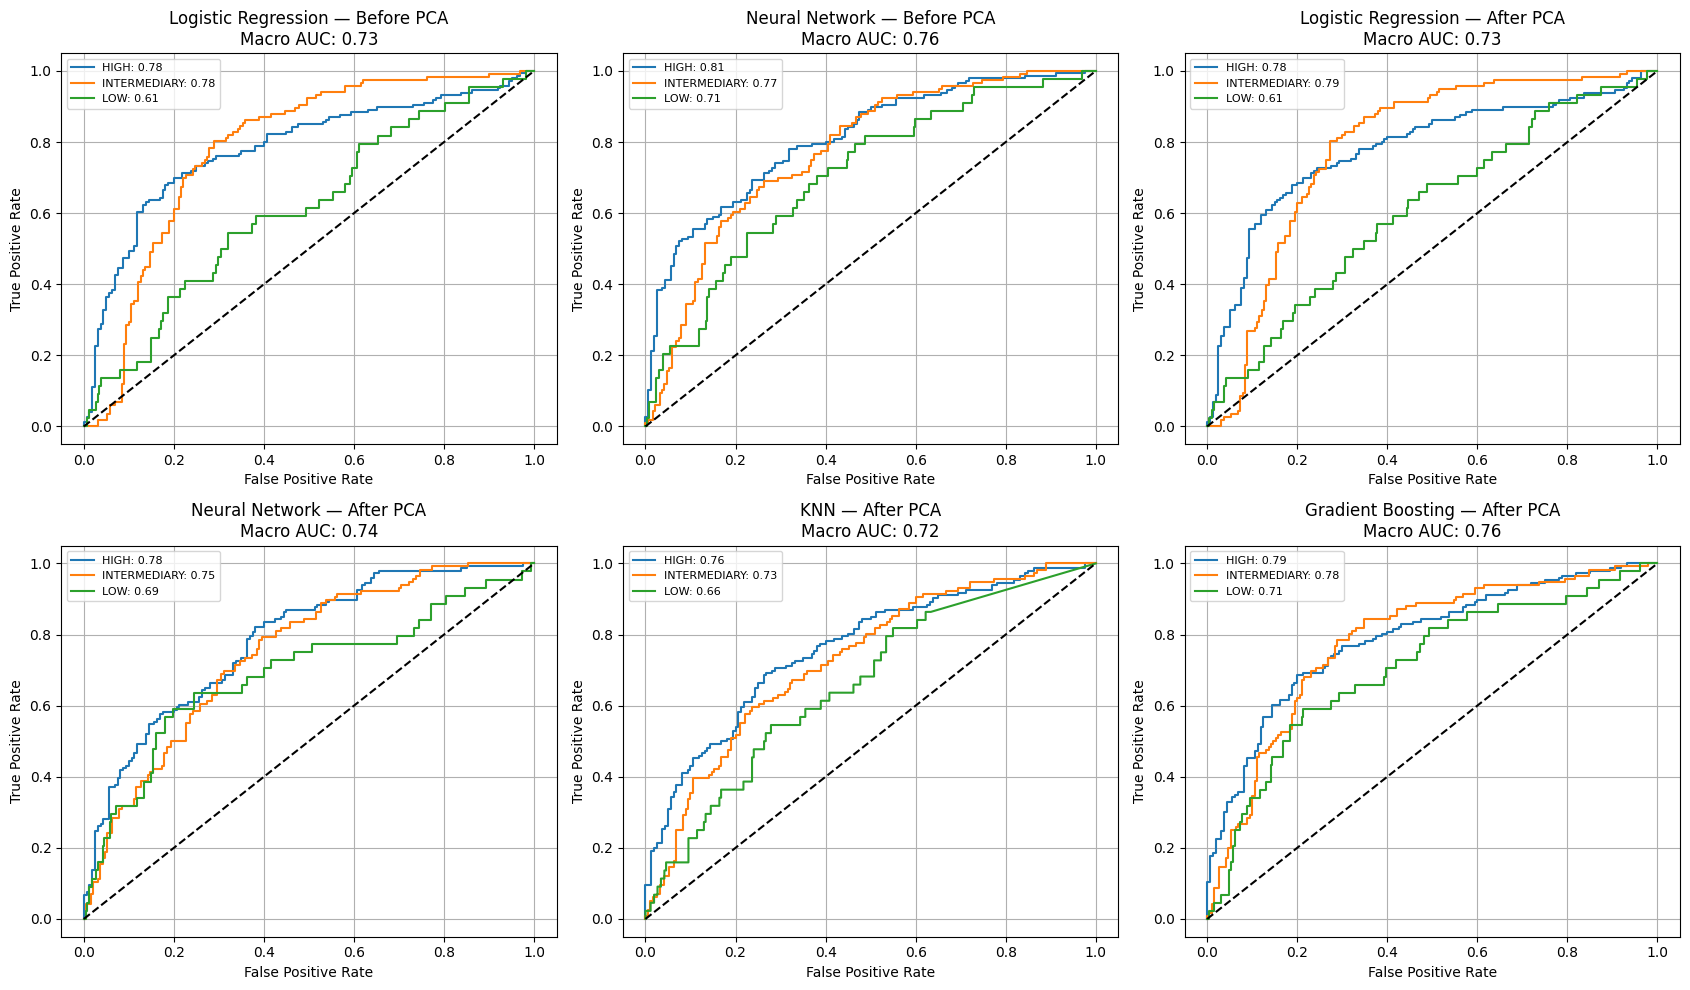

In [ ]:
fig, axes = plt.subplots(
    2,
    3,
    figsize=(17, 10)
)

axes = axes.flatten()

for ax, (model_name, probabilities) in zip(
    axes,
    roc_models.items()
):

    for i, class_name in enumerate(CLASS_NAMES):

        fpr, tpr, _ = roc_curve(
            y_test_binary[:, i],
            probabilities[:, i]
        )

        auc_score = roc_auc_score(
            y_test_binary[:, i],
            probabilities[:, i]
        )

        ax.plot(
            fpr,
            tpr,
            label=f"{class_name}: {auc_score:.2f}"
        )

    macro_auc = roc_auc_score(
        y_test_binary,
        probabilities,
        average="macro"
    )

    ax.plot(
        [0, 1],
        [0, 1],
        "k--"
    )

    ax.set_title(
        f"{model_name}\nMacro AUC: {macro_auc:.2f}"
    )

    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(fontsize=8)
    ax.grid()

plt.tight_layout()
plt.show()

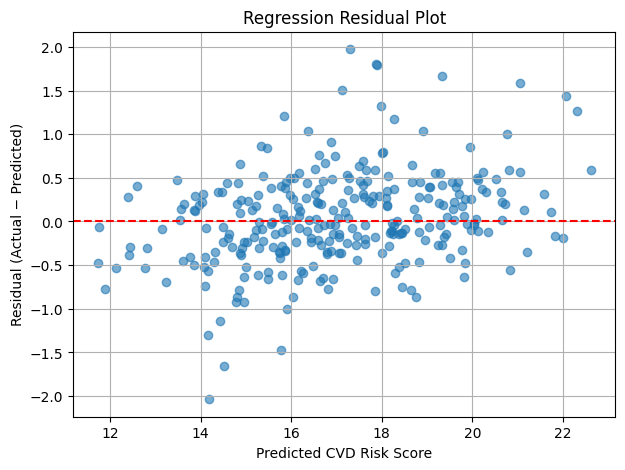

In [ ]:
residuals = y_test_reg - y_pred_reg

plt.figure(figsize=(7, 5))

plt.scatter(
    y_pred_reg,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted CVD Risk Score")
plt.ylabel("Residual (Actual − Predicted)")
plt.title("Regression Residual Plot")
plt.grid()
plt.show()